# EDGE AI Project

## PCB Manufacturing Defcet Detection

In [10]:
!pip install ultralytics opencv-python matplotlib tqdm lxml

In [11]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [12]:
BASE_PATH = "/content/drive/MyDrive/PCB_defect_detection/PCB_DATASET"
IMG_DIR = BASE_PATH + "/images"
XML_DIR = BASE_PATH + "/Annotations"

In [13]:
!ls $IMG_DIR | head
!ls $XML_DIR | head

Missing_hole
Mouse_bite
Open_circuit
Short
Spur
Spurious_copper
Missing_hole
Mouse_bite
Open_circuit
Short
Spur
Spurious_copper


In [14]:
import os

# Get filenames (without extension)
image_files = set([os.path.splitext(f)[0] for f in os.listdir(IMG_DIR) if f.endswith(('.jpg', '.png'))])
xml_files = set([os.path.splitext(f)[0] for f in os.listdir(XML_DIR) if f.endswith('.xml')])

# Check mismatches
missing_xml = image_files - xml_files
missing_images = xml_files - image_files

print("Images without XML:", len(missing_xml))
print("XML without images:", len(missing_images))

if len(missing_xml) > 0:
    print("Example missing XML:", list(missing_xml)[:5])

if len(missing_images) > 0:
    print("Example missing images:", list(missing_images)[:5])

Images without XML: 0
XML without images: 0


In [15]:
import cv2
import xml.etree.ElementTree as ET
import matplotlib.pyplot as plt

# Get first XML file from nested folders
sample_xml = None

for root_dir, _, files in os.walk(XML_DIR):
    for file in files:
        if file.endswith(".xml"):
            sample_xml = os.path.join(root_dir, file)
            break
    if sample_xml:
        break



In [16]:
tree = ET.parse(sample_xml)
root = tree.getroot()

filename = root.find("filename").text
class_folder = root.find("folder").text

img_path = os.path.join(IMG_DIR, class_folder, filename)

# Fix path if needed (Windows)
if not os.path.exists(img_path):
    filename = root.find("filename").text
    img_path = os.path.join(IMG_DIR, filename)

img = cv2.imread(img_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)



(np.float64(-0.5), np.float64(2528.5), np.float64(2529.5), np.float64(-0.5))

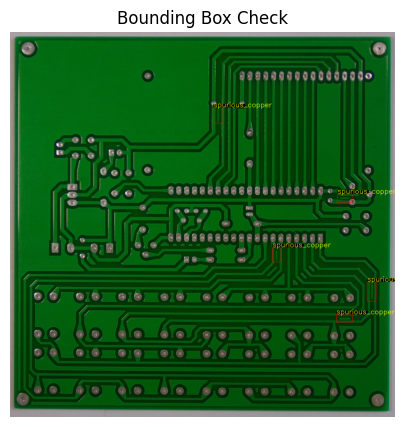

In [17]:
# Draw bounding boxes
for obj in root.findall("object"):
    name = obj.find("name").text
    bbox = obj.find("bndbox")

    xmin = int(float(bbox.find("xmin").text))
    ymin = int(float(bbox.find("ymin").text))
    xmax = int(float(bbox.find("xmax").text))
    ymax = int(float(bbox.find("ymax").text))

    # Clamp properly
    xmin = max(0, xmin)
    ymin = max(0, ymin)
    xmax = min(img.shape[1], xmax)
    ymax = min(img.shape[0], ymax)

    cv2.rectangle(img, (xmin, ymin), (xmax, ymax), (255, 0, 0), 2)
    # Background box for text
    text_y = max(20, ymin)
    (text_w, text_h), _ = cv2.getTextSize(name, cv2.FONT_HERSHEY_SIMPLEX, 0.8, 2)

    cv2.rectangle(img,
                (xmin, text_y - text_h - 5),
                (xmin + text_w, text_y),
                (0, 0, 0),  # black background
                -1)

    cv2.putText(img,
                name,
                (xmin, text_y - 2),
                cv2.FONT_HERSHEY_SIMPLEX,
                1.5,
                (255, 255, 0),
                2)

plt.figure(figsize=(10,5))
plt.imshow(img)
plt.title("Bounding Box Check")
plt.axis("off")

In [18]:
from tqdm import tqdm

# Defects to detect

In [19]:
classes = [
    "missing_hole",
    "mouse_bite",
    "open_circuit",
    "short",
    "spur",
    "spurious_copper"
]

In [20]:
import os
import xml.etree.ElementTree as ET
from tqdm import tqdm

LABEL_DIR = BASE_PATH + "/labels"
os.makedirs(LABEL_DIR, exist_ok=True)

def convert_xml(xml_path):
    tree = ET.parse(xml_path)
    root = tree.getroot()

    filename = root.find("filename").text
    folder = root.find("folder").text

    size = root.find("size")
    w = int(size.find("width").text)
    h = int(size.find("height").text)

    label_path = os.path.join(LABEL_DIR, filename.replace(".jpg", ".txt"))

    with open(label_path, "w") as f:
        for obj in root.findall("object"):
            cls = obj.find("name").text.lower()

            if cls not in classes:
                continue

            cls_id = classes.index(cls)

            bbox = obj.find("bndbox")

            xmin = int(float(bbox.find("xmin").text))
            ymin = int(float(bbox.find("ymin").text))
            xmax = int(float(bbox.find("xmax").text))
            ymax = int(float(bbox.find("ymax").text))

            xmin = max(0, xmin)
            ymin = max(0, ymin)
            xmax = min(w, xmax)
            ymax = min(h, ymax)

            if xmax <= xmin or ymax <= ymin:
                continue

            x_center = (xmin + xmax) / 2 / w
            y_center = (ymin + ymax) / 2 / h
            bw = (xmax - xmin) / w
            bh = (ymax - ymin) / h

            f.write(f"{cls_id} {x_center} {y_center} {bw} {bh}\n")

# Run conversion
xml_files = []
for root_dir, _, files in os.walk(XML_DIR):
    for file in files:
        if file.endswith(".xml"):
            xml_files.append(os.path.join(root_dir, file))

for xml_file in tqdm(xml_files):
    convert_xml(xml_file)

print("✅ Conversion done")

  0%|          | 2/693 [00:03<21:51,  1.90s/it]


KeyboardInterrupt: 

In [ ]:
print("Images:", len(xml_files))
print("Labels:", len(os.listdir(LABEL_DIR)))

In [ ]:
for folder in ["images/train", "images/val", "images/test",
               "labels/train", "labels/val", "labels/test"]:

    path = os.path.join(BASE_PATH, folder)

    if os.path.exists(path):
        shutil.rmtree(path)

print("✅ Old splits removed")

In [ ]:
# Create new folders
for folder in ["images/train", "images/val", "images/test",
               "labels/train", "labels/val", "labels/test"]:

    os.makedirs(os.path.join(BASE_PATH, folder), exist_ok=True)

print("✅ New folders created")

In [ ]:
IMG_DIR = BASE_PATH + "/images"
LABEL_DIR = BASE_PATH + "/labels"

all_images = []

for root_dir, _, files in os.walk(IMG_DIR):

    # skip split folders if present
    if any(x in root_dir for x in ["train", "val", "test"]):
        continue

    for file in files:
        if file.endswith(".jpg"):
            all_images.append(os.path.join(root_dir, file))

print("Total images:", len(all_images))

In [ ]:
import random

random.seed(42)
random.shuffle(all_images)

n = len(all_images)

train_end = int(0.7 * n)
val_end = int(0.9 * n)

train_files = all_images[:train_end]
val_files = all_images[train_end:val_end]
test_files = all_images[val_end:]

print("Train:", len(train_files))
print("Val:", len(val_files))
print("Test:", len(test_files))

In [ ]:
def copy_files(file_list, split):

    for img_path in file_list:
        name = os.path.basename(img_path)
        label = name.replace(".jpg", ".txt")

        # destination paths
        img_dest = os.path.join(BASE_PATH, "images", split, name)
        lbl_dest = os.path.join(BASE_PATH, "labels", split, label)

        shutil.copy(img_path, img_dest)

        label_path = os.path.join(LABEL_DIR, label)

        if os.path.exists(label_path):
            shutil.copy(label_path, lbl_dest)
        else:
            print(f"⚠️ Missing label: {label}")

copy_files(train_files, "train")
copy_files(val_files, "val")
copy_files(test_files, "test")

print("✅ Split completed")

In [ ]:
def count_check(split):
    img_count = len(os.listdir(os.path.join(BASE_PATH, "images", split)))
    lbl_count = len(os.listdir(os.path.join(BASE_PATH, "labels", split)))
    print(f"{split}: images={img_count}, labels={lbl_count}")

count_check("train")
count_check("val")
count_check("test")

#### yaml File

In [ ]:
yaml_content = f"""
path: {BASE_PATH}

train: images/train
val: images/val
test: images/test

nc: 6

names:
  0: missing_hole
  1: mouse_bite
  2: open_circuit
  3: short
  4: spur
  5: spurious_copper
"""

with open("pcb.yaml", "w") as f:
    f.write(yaml_content)

print("✅ YAML updated")

### Training Yolo nano Model

In [ ]:
from ultralytics import YOLO

model = YOLO("yolov8n.pt")

model.train(
    data="pcb.yaml",
    epochs=50,
    imgsz=800,
    batch=16,

    hsv_h=0.015,
    hsv_s=0.7,
    hsv_v=0.4,

    degrees=10,
    translate=0.1,
    scale=0.5,

    flipud=0.5,
    fliplr=0.5,

    mosaic=1.0,
    mixup=0.2,

    name="yolov8n_clean"
)

In [ ]:
from PIL import Image

img = Image.open("runs/detect/yolov8n_clean/results.png")

plt.figure(figsize=(12,8))
plt.imshow(img)
plt.axis("off")

In [ ]:
img = Image.open("runs/detect/yolov8n_pcb/confusion_matrix.png")

plt.figure(figsize=(8,8))
plt.imshow(img)
plt.axis("off")

In [ ]:
model = YOLO("runs/detect/yolov8n_clean/weights/best.pt")

model.predict(
    source="/content/drive/MyDrive/PCB_defect_detection/PCB_DATASET/images/test",
    save=True,
    conf=0.25
)

In [ ]:
PRED_DIR = "runs/detect/predict-2"

images = os.listdir(PRED_DIR)[:5]  # show first 5

plt.figure(figsize=(15,10))

for i, img_name in enumerate(images):
    img = Image.open(os.path.join(PRED_DIR, img_name))

    plt.subplot(2,3,i+1)
    plt.imshow(img)
    plt.title(img_name)
    plt.axis("off")

plt.tight_layout()

In [ ]:
import pandas as pd

df = pd.read_csv("runs/detect/yolov8n_pcb/results.csv")
df.tail()

### Training Yolo small model

In [ ]:
from ultralytics import YOLO

model = YOLO("yolov8s.pt")

model.train(
    data="pcb.yaml",
    epochs=70,
    imgsz=1024,   # 🔥 increase resolution
    batch=12,

    hsv_h=0.015,
    hsv_s=0.7,
    hsv_v=0.4,

    degrees=10,
    translate=0.1,
    scale=0.5,

    flipud=0.5,
    fliplr=0.5,

    mosaic=1.0,
    mixup=0.2,

    name="yolov8s_pcb2"
)

In [ ]:
import torch
import torch.nn.utils.prune as prune

# Load trained model
model = YOLO("runs/detect/train/weights/best.pt")

# Access PyTorch model
pt_model = model.model

print("🔧 Applying pruning...")

# Apply pruning to Conv layers
for name, module in pt_model.named_modules():
    if isinstance(module, torch.nn.Conv2d):
        prune.l1_unstructured(module, name="weight", amount=0.3)  # 30% pruning

# Remove pruning reparameterization
for name, module in pt_model.named_modules():
    if isinstance(module, torch.nn.Conv2d):
        try:
            prune.remove(module, 'weight')
        except:
            pass

print("✅ Pruning completed")

In [ ]:
import shutil

shutil.copytree(
    "runs/detect/yolov8n_clean",
    "/content/drive/MyDrive/PCB_RESULTS/yolov8n_clean",
    dirs_exist_ok=True
)

shutil.copytree(
    "runs/detect/yolov8s_pcb2",
    "/content/drive/MyDrive/PCB_RESULTS/yolov8s_pcb",
    dirs_exist_ok=True
)

print("✅ Models saved to Drive")

In [ ]:
from ultralytics import YOLO

model_n = YOLO("/content/drive/MyDrive/PCB_RESULTS/yolov8n_clean/weights/best.pt")
model_s = YOLO("/content/drive/MyDrive/PCB_RESULTS/yolov8s_pcb/weights/best.pt")

In [ ]:
yaml_content = f"""
path: {BASE_PATH}

train: images/train
val: images/val
test: images/test

nc: 6

names:
  0: missing_hole
  1: mouse_bite
  2: open_circuit
  3: short
  4: spur
  5: spurious_copper
"""

with open("pcb.yaml", "w") as f:
    f.write(yaml_content)

print("✅ YAML recreated")

In [ ]:
yaml_path = "/content/drive/MyDrive/PCB_RESULTS/pcb.yaml"

with open(yaml_path, "w") as f:
    f.write(yaml_content)

In [ ]:
metrics_n = model_n.val(data="pcb.yaml", split="test")
metrics_s = model_s.val(data="pcb.yaml", split="test")

In [ ]:
model_n.predict(source=f"{BASE_PATH}/images/test", save=True, name="pred_n")
model_s.predict(source=f"{BASE_PATH}/images/test", save=True, name="pred_s")

In [ ]:
print("YOLOv8n")
print("Precision:", metrics_n.box.p)
print("Recall:", metrics_n.box.r)
print("mAP50:", metrics_n.box.map50)
print("mAP50-95:", metrics_n.box.map)

print("\nYOLOv8s")
print("Precision:", metrics_s.box.p)
print("Recall:", metrics_s.box.r)
print("mAP50:", metrics_s.box.map50)
print("mAP50-95:", metrics_s.box.map)

In [ ]:
print(metrics_n)
print(metrics_s)

In [ ]:
model_s.predict(source=f"{BASE_PATH}/images/test", save=True, conf=0.25)

In [ ]:
import os
from PIL import Image
import matplotlib.pyplot as plt

PRED_DIR = "/content/runs/detect/pred_s"

images = os.listdir(PRED_DIR)[:5]

plt.figure(figsize=(15,10))

for i, img_name in enumerate(images):
    img = Image.open(os.path.join(PRED_DIR, img_name))

    plt.subplot(2,3,i+1)
    plt.imshow(img)
    plt.axis("off")
    pip3 install ultralytics openvino opencv-python

plt.show()

In [ ]:
model_s.export(format="openvino")

In [ ]:
import shutil

shutil.copytree(
    "/content/drive/MyDrive/PCB_RESULTS/yolov8s_pcb/weights/best_openvino_model",
    "/content/drive/MyDrive/PCB_RESULTS/openvino_model",
    dirs_exist_ok=True
)

print("✅ OpenVINO model saved")

In [ ]:
model_s.export(format="tflite")